# Results Analysis Notebook

This notebook reads experiment outputs directly from the `results/` folder and generates analysis plots without hardcoding result values.

In [37]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

ROOT = Path('.')
RESULTS_DIR = ROOT / 'results' 
SCALABILITY_DIR = RESULTS_DIR / 'scalability'
FIG_DPI = 700

plt.rcParams.update({
    'figure.dpi': FIG_DPI,
    'savefig.dpi': FIG_DPI,
    'savefig.format': 'png',
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    # 'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'axes.labelweight': 'bold',
    'legend.fontsize': 10,
    'legend.frameon': True,
    'legend.framealpha': 0.95,
    'legend.markerscale': 1.2,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'grid.linestyle': ':',
    'grid.linewidth': 0.8,
    'grid.alpha': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

def load_json(path: Path) -> dict:
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)

def normalize_method_name(name: str) -> str:
    return name.replace('_', ' ').title()

def collect_eval_points(exp_data: dict) -> pd.DataFrame:
    rows = []
    for r in exp_data.get('rounds', []):
        metrics = r.get('eval_metrics', {})
        if metrics:
            row = {'round': r.get('round'), 'avg_loss': r.get('avg_loss'), 'round_time_sec': r.get('round_time_sec')}
            row.update(metrics)
            rows.append(row)
    return pd.DataFrame(rows)

def last_eval_metrics(exp_data: dict) -> dict:
    eval_df = collect_eval_points(exp_data)
    if eval_df.empty:
        return {}
    return eval_df.sort_values('round').iloc[-1].to_dict()

print(f'Results dir exists: {RESULTS_DIR.exists()}')
print(f'Scalability dir exists: {SCALABILITY_DIR.exists()}')

Results dir exists: True
Scalability dir exists: True


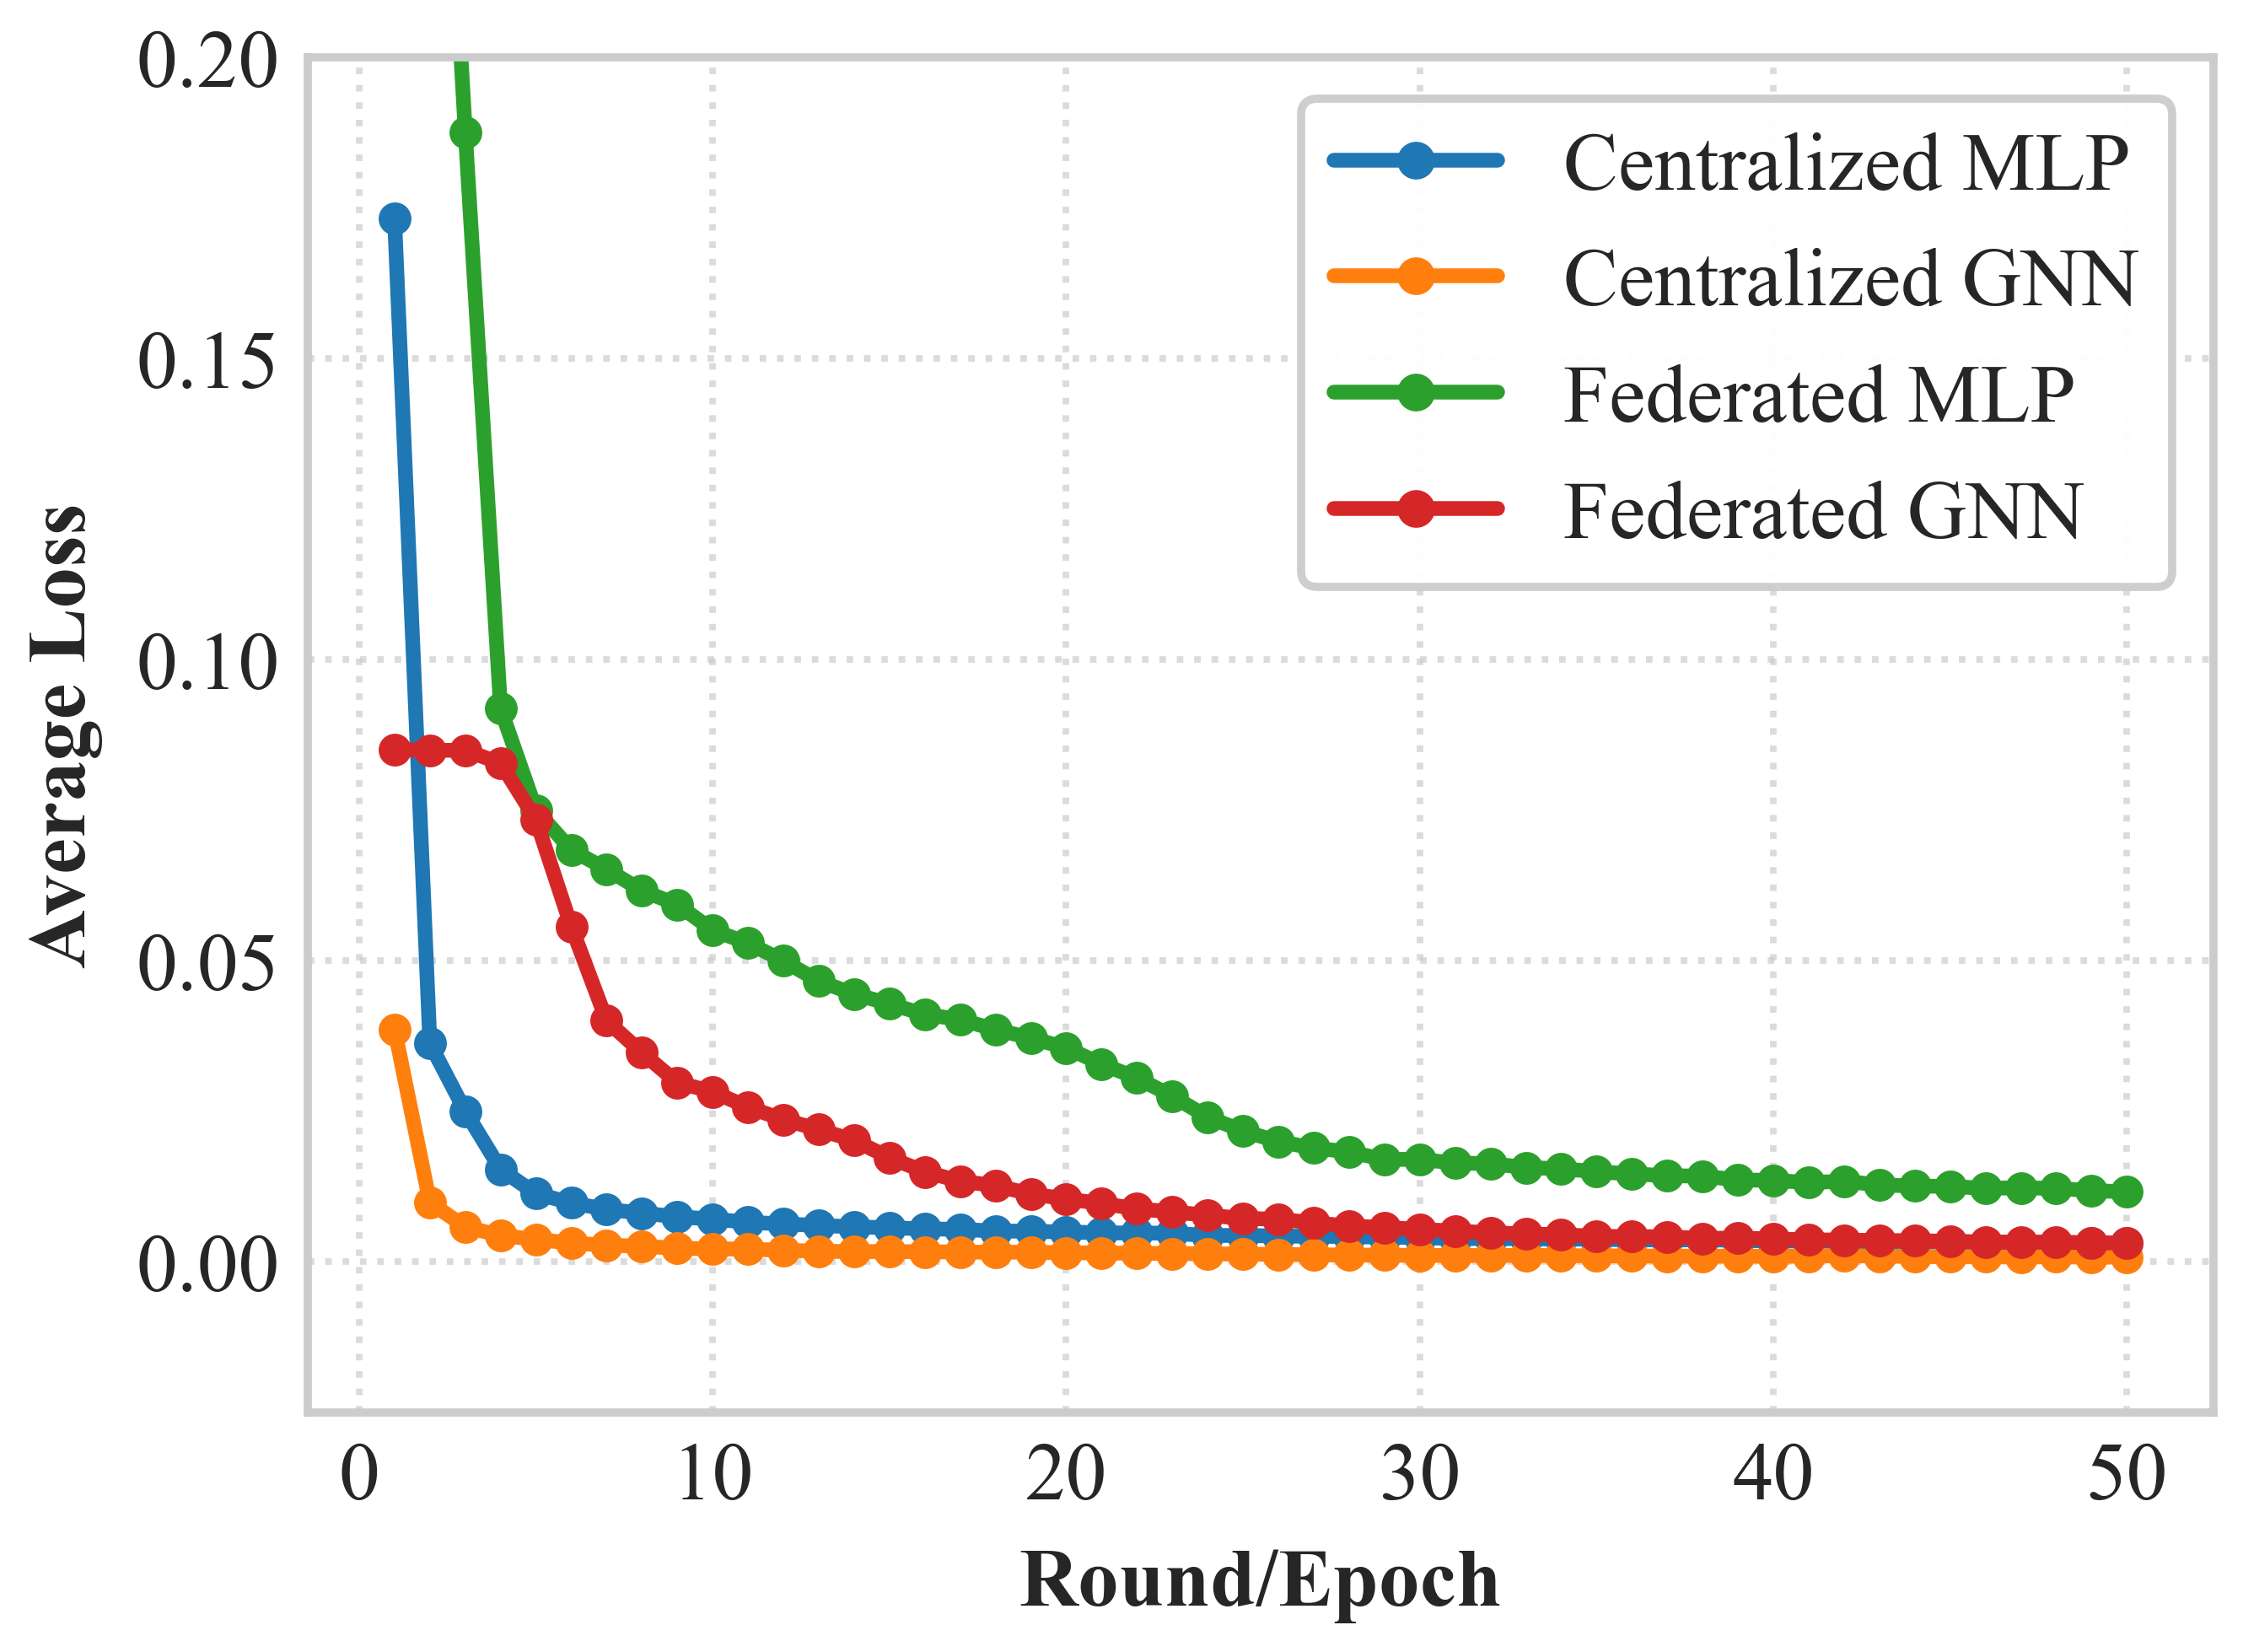

In [39]:
# Training curves: Centralized MLP/GNN vs Federated MLP/GNN
model_files = {
    "Centralized MLP": ["centralized_mlp.json"],
    "Centralized GNN": ["centralized_gnn.json"],
    "Federated MLP": ["federated_mlp.json"],
    "Federated GNN": ["fedgnn.json", "federated_gnn.json"],
}

def extract_training_curve(exp_data: dict) -> pd.DataFrame:
    for seq_key in ["rounds", "epochs"]:
        seq = exp_data.get(seq_key, [])
        if isinstance(seq, list) and seq and isinstance(seq[0], dict):
            rows = []
            for item in seq:
                x = item.get("round", item.get("epoch", item.get("step")))
                y = item.get("avg_loss", item.get("loss", item.get("train_loss")))
                if x is not None and y is not None:
                    rows.append({"x": x, "avg_loss": y})
            if rows:
                return pd.DataFrame(rows).sort_values("x")

    hist = exp_data.get("history", {})
    if isinstance(hist, dict):
        loss = hist.get("avg_loss", hist.get("loss", hist.get("train_loss")))
        if isinstance(loss, list) and len(loss) > 0:
            return pd.DataFrame({"x": np.arange(1, len(loss) + 1), "avg_loss": loss})

    return pd.DataFrame(columns=["x", "avg_loss"])

fig, ax = plt.subplots(figsize=(4, 3))

for label, candidates in model_files.items():
    path = next((RESULTS_DIR / name for name in candidates if (RESULTS_DIR / name).exists()), None)
    if path is None:
        print(f"Missing file for {label}: tried {candidates}")
        continue

    exp_data = load_json(path)
    curve_df = extract_training_curve(exp_data)
    if curve_df.empty:
        print(f"No training curve found in {path.name}")
        continue

    ax.plot(curve_df["x"], curve_df["avg_loss"], marker="o", markersize=3, linewidth=1.8, label=label)

# ax.set_title("Training Curves: Centralized vs Federated Models")
ax.set_xlabel("Round/Epoch")
ax.set_ylabel("Average Loss")
# ax.set_xlim([0,20])
ax.set_ylim([-0.025,0.20])
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig(RESULTS_DIR / 'figures'/ "fig_training_curves_ieee.pdf")


,mean_error,median_error,p75_error,p90_error,rmse,cep_5m,cep_10m,max_error,std_error
Centralized MLP,8.464513,7.093222,10.900912,16.440984,10.564702,0.305495,0.707692,48.779209,6.321782
Centralized GNN,8.935910,5.110211,10.673689,20.849812,14.197020,0.492308,0.729670,91.141571,11.031993
Federated GNN,10.211837,7.451213,13.759603,21.811483,13.173459,0.309890,0.615385,44.640259,8.322165
Federated MLP,14.378921,12.087333,19.046018,27.337416,17.491764,0.125275,0.380220,61.530361,9.960347


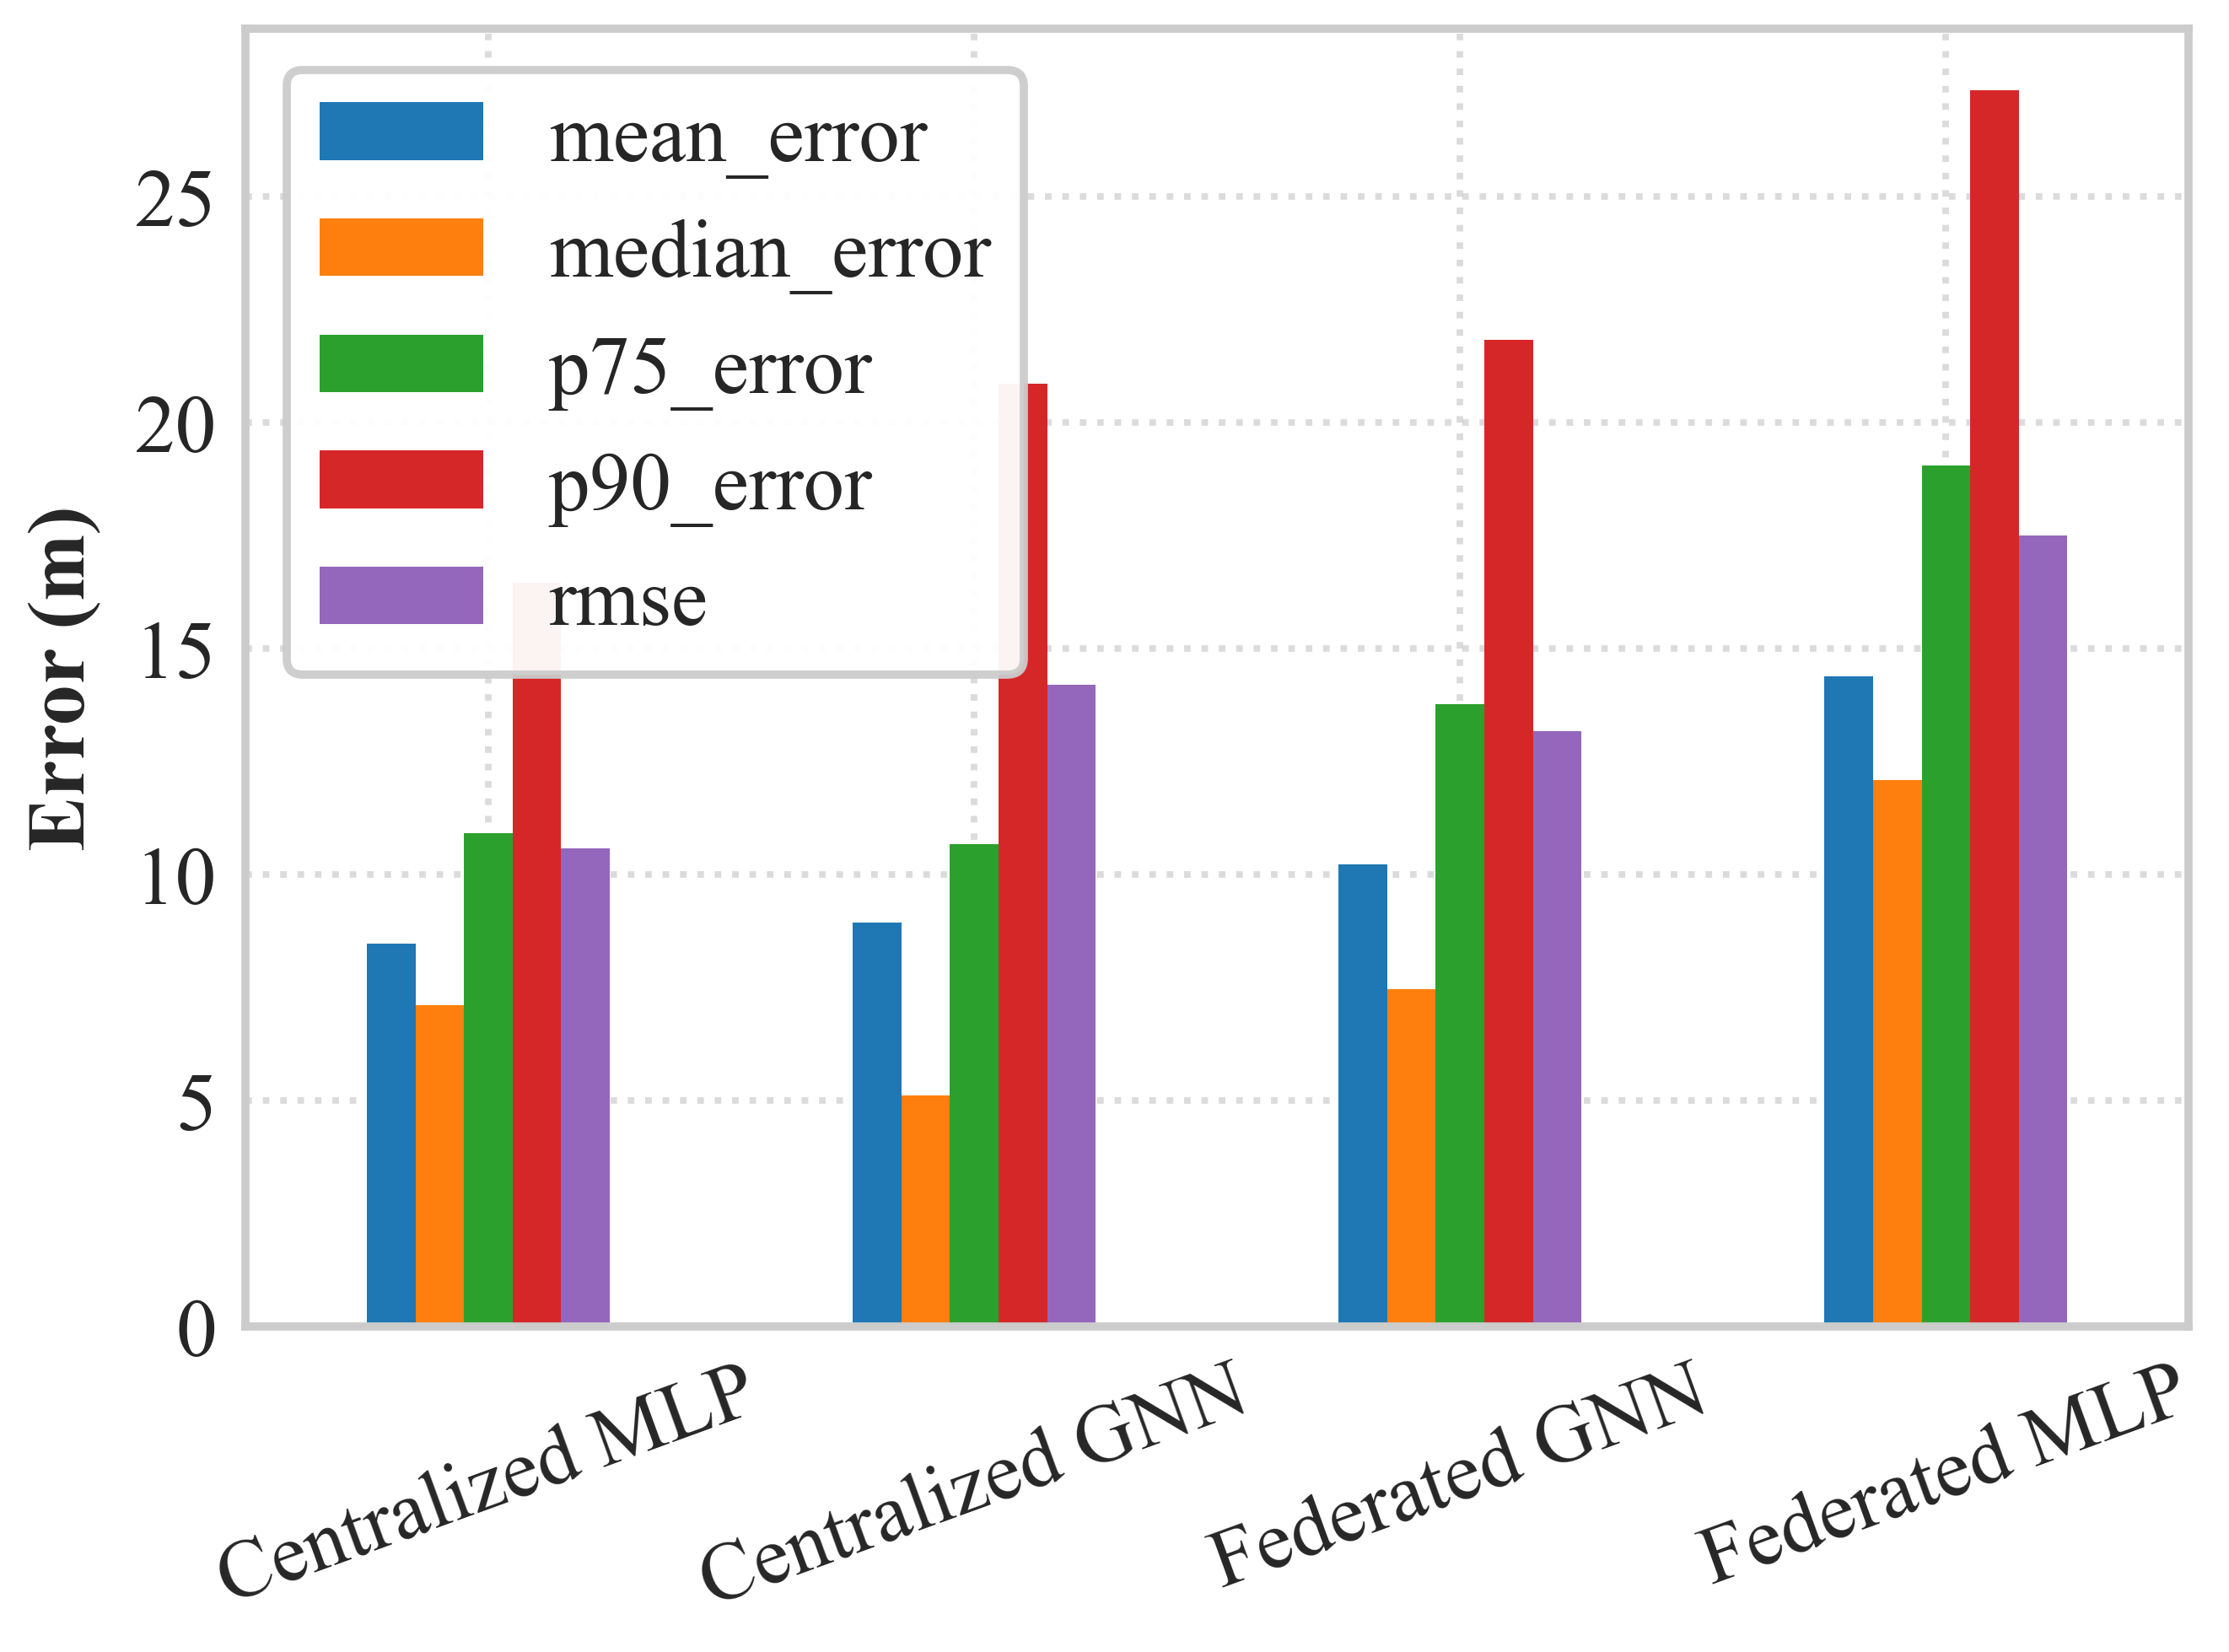

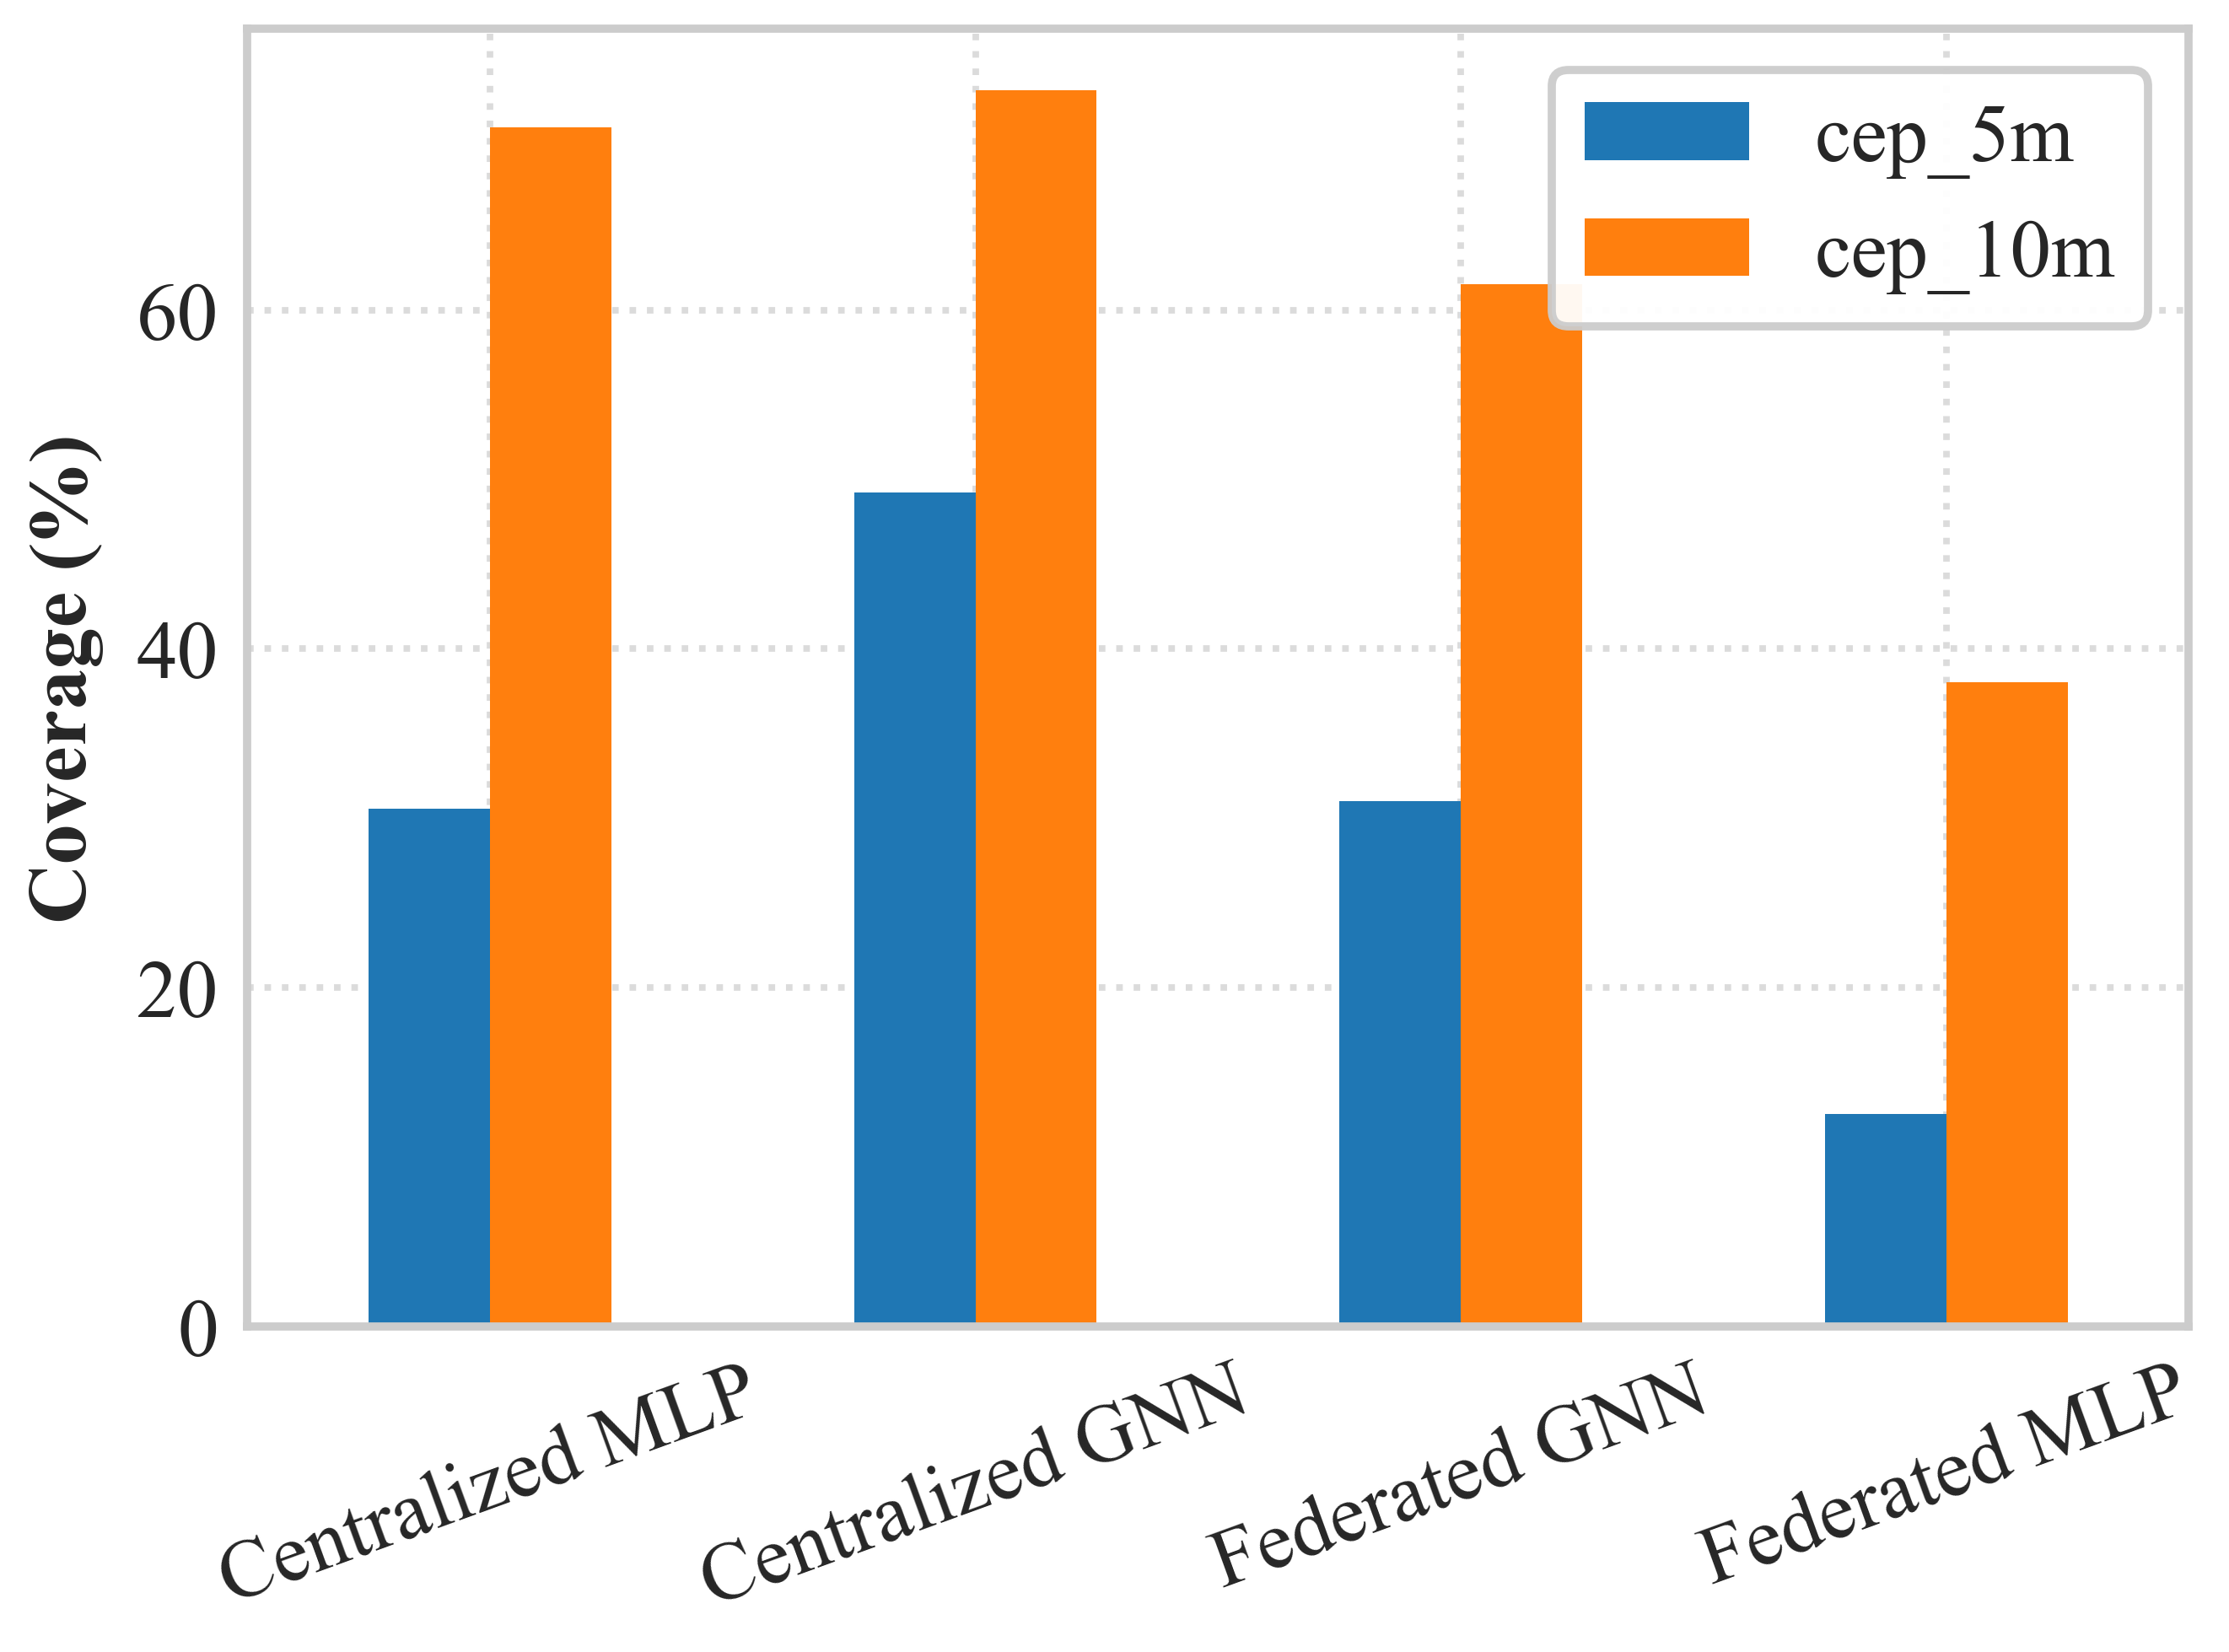

In [48]:
# Validation comparison in Cell 3 style (separate plots, includes coverage), excluding k-NN
model_files_val = {
    "Centralized MLP": ["centralized_mlp.json"],
    "Centralized GNN": ["centralized_gnn.json"],
    "Federated MLP": ["federated_mlp.json"],
    "Federated GNN": ["fedgnn.json", "federated_gnn.json"],
}

figures_dir = RESULTS_DIR / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

comparison_val = {}
for label, candidates in model_files_val.items():
    path = next((RESULTS_DIR / name for name in candidates if (RESULTS_DIR / name).exists()), None)
    if path is None:
        print(f"Missing file for {label}: tried {candidates}")
        continue
    exp_data = load_json(path)
    final_metrics = last_eval_metrics(exp_data)
    if final_metrics:
        comparison_val[label] = {
            k: v for k, v in final_metrics.items()
            if k in {
                'mean_error', 'median_error', 'p75_error', 'p90_error',
                'rmse', 'cep_5m', 'cep_10m', 'max_error', 'std_error'
            }
        }

val_comp_df = pd.DataFrame(comparison_val).T
val_comp_df = val_comp_df.sort_values('mean_error')
display(val_comp_df)

error_metrics = ['mean_error', 'median_error', 'p75_error', 'p90_error', 'rmse']
coverage_metrics = ['cep_5m', 'cep_10m']

# Figure 1: validation error metrics
fig, ax = plt.subplots(figsize=(4, 3))
val_comp_df[error_metrics].plot(kind='bar', ax=ax)
# ax.set_title('Validation Error Metrics by Method (No k-NN)')
ax.set_ylabel('Error (m)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
fig.savefig(figures_dir / 'fig_validation_error_comparison_ieee.pdf')
plt.show()

# Figure 2: validation coverage metrics
fig, ax = plt.subplots(figsize=(4, 3))
(val_comp_df[coverage_metrics] * 100).plot(kind='bar', ax=ax)
# ax.set_title('Validation Coverage Metrics by Method (No k-NN)')
ax.set_ylabel('Coverage (%)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
fig.savefig(figures_dir / 'fig_validation_coverage_comparison_ieee.pdf')
plt.show()

,num_clients,mean_error
2,2,12.999093
3,3,8.758788
4,5,8.857689
5,7,11.501864
6,9,9.868939
0,11,10.040158
1,13,13.282784


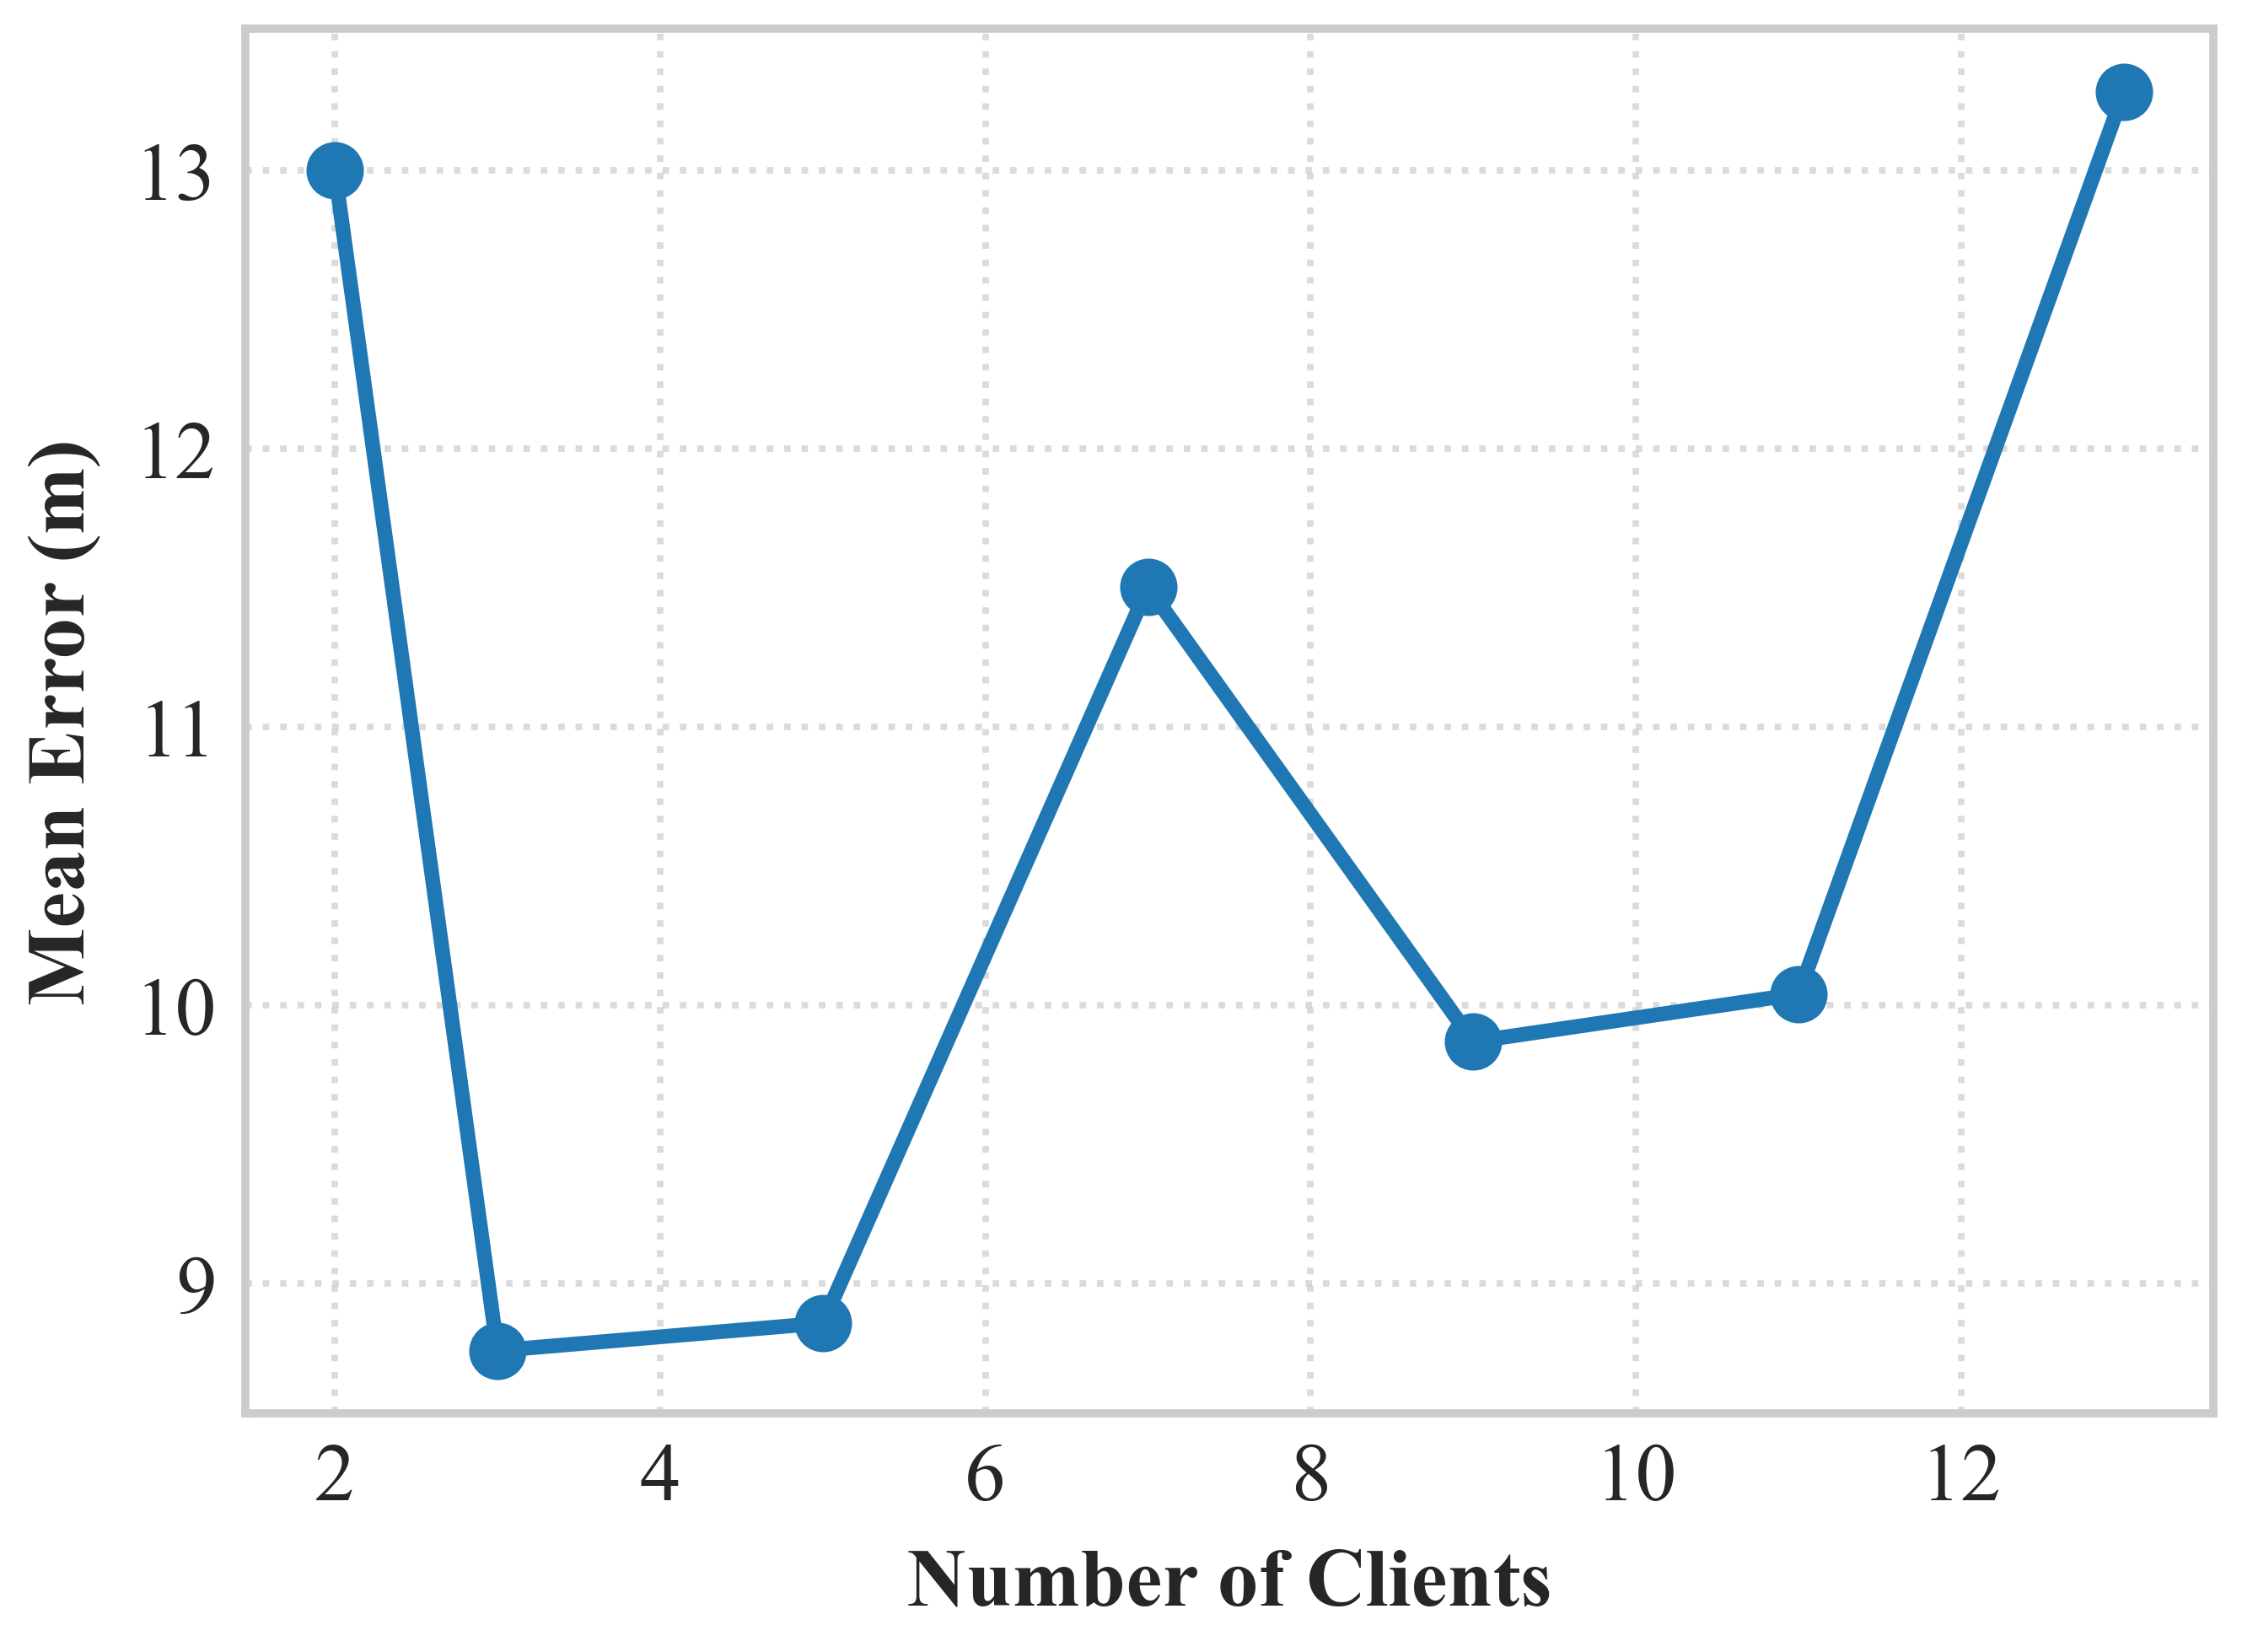

In [53]:
# Mean error vs number of clients (scalability sweep)
client_files = sorted(SCALABILITY_DIR.glob('scale_domains_*.json'))
client_rows = []

for fp in client_files:
    data = load_json(fp)

    cfg = data.get('config', {}) if isinstance(data, dict) else {}
    num_clients = cfg.get('num_clients')
    if num_clients is None:
        match = re.search(r'scale_domains_(\d+)$', fp.stem)
        num_clients = int(match.group(1)) if match else None
    if num_clients is None:
        continue

    eval_df = collect_eval_points(data)
    if eval_df.empty:
        continue

    final_eval = eval_df.sort_values('round').iloc[-1]
    mean_error = final_eval.get('mean_error')
    if mean_error is None:
        continue

    client_rows.append({
        'num_clients': int(num_clients),
        'mean_error': float(mean_error)
    })

if not client_rows:
    print("No client scalability files found (expected pattern: scale_domains_*.json with config.num_clients).")
else:
    clients_df = pd.DataFrame(client_rows).dropna().sort_values('num_clients')
    display(clients_df)

    figures_dir = RESULTS_DIR / 'figures'
    figures_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(clients_df['num_clients'], clients_df['mean_error'], marker='o', linewidth=1.8)
    ax.set_xlabel('Number of Clients')
    ax.set_ylabel('Mean Error (m)')
    plt.tight_layout()
    fig.savefig(figures_dir / 'fig_scalability_clients_mean_error_ieee.pdf')
    plt.show()

,max_rps,mean_error
2,25,11.376196
3,50,10.174493
4,75,10.136570
0,100,9.947561
1,150,10.534107


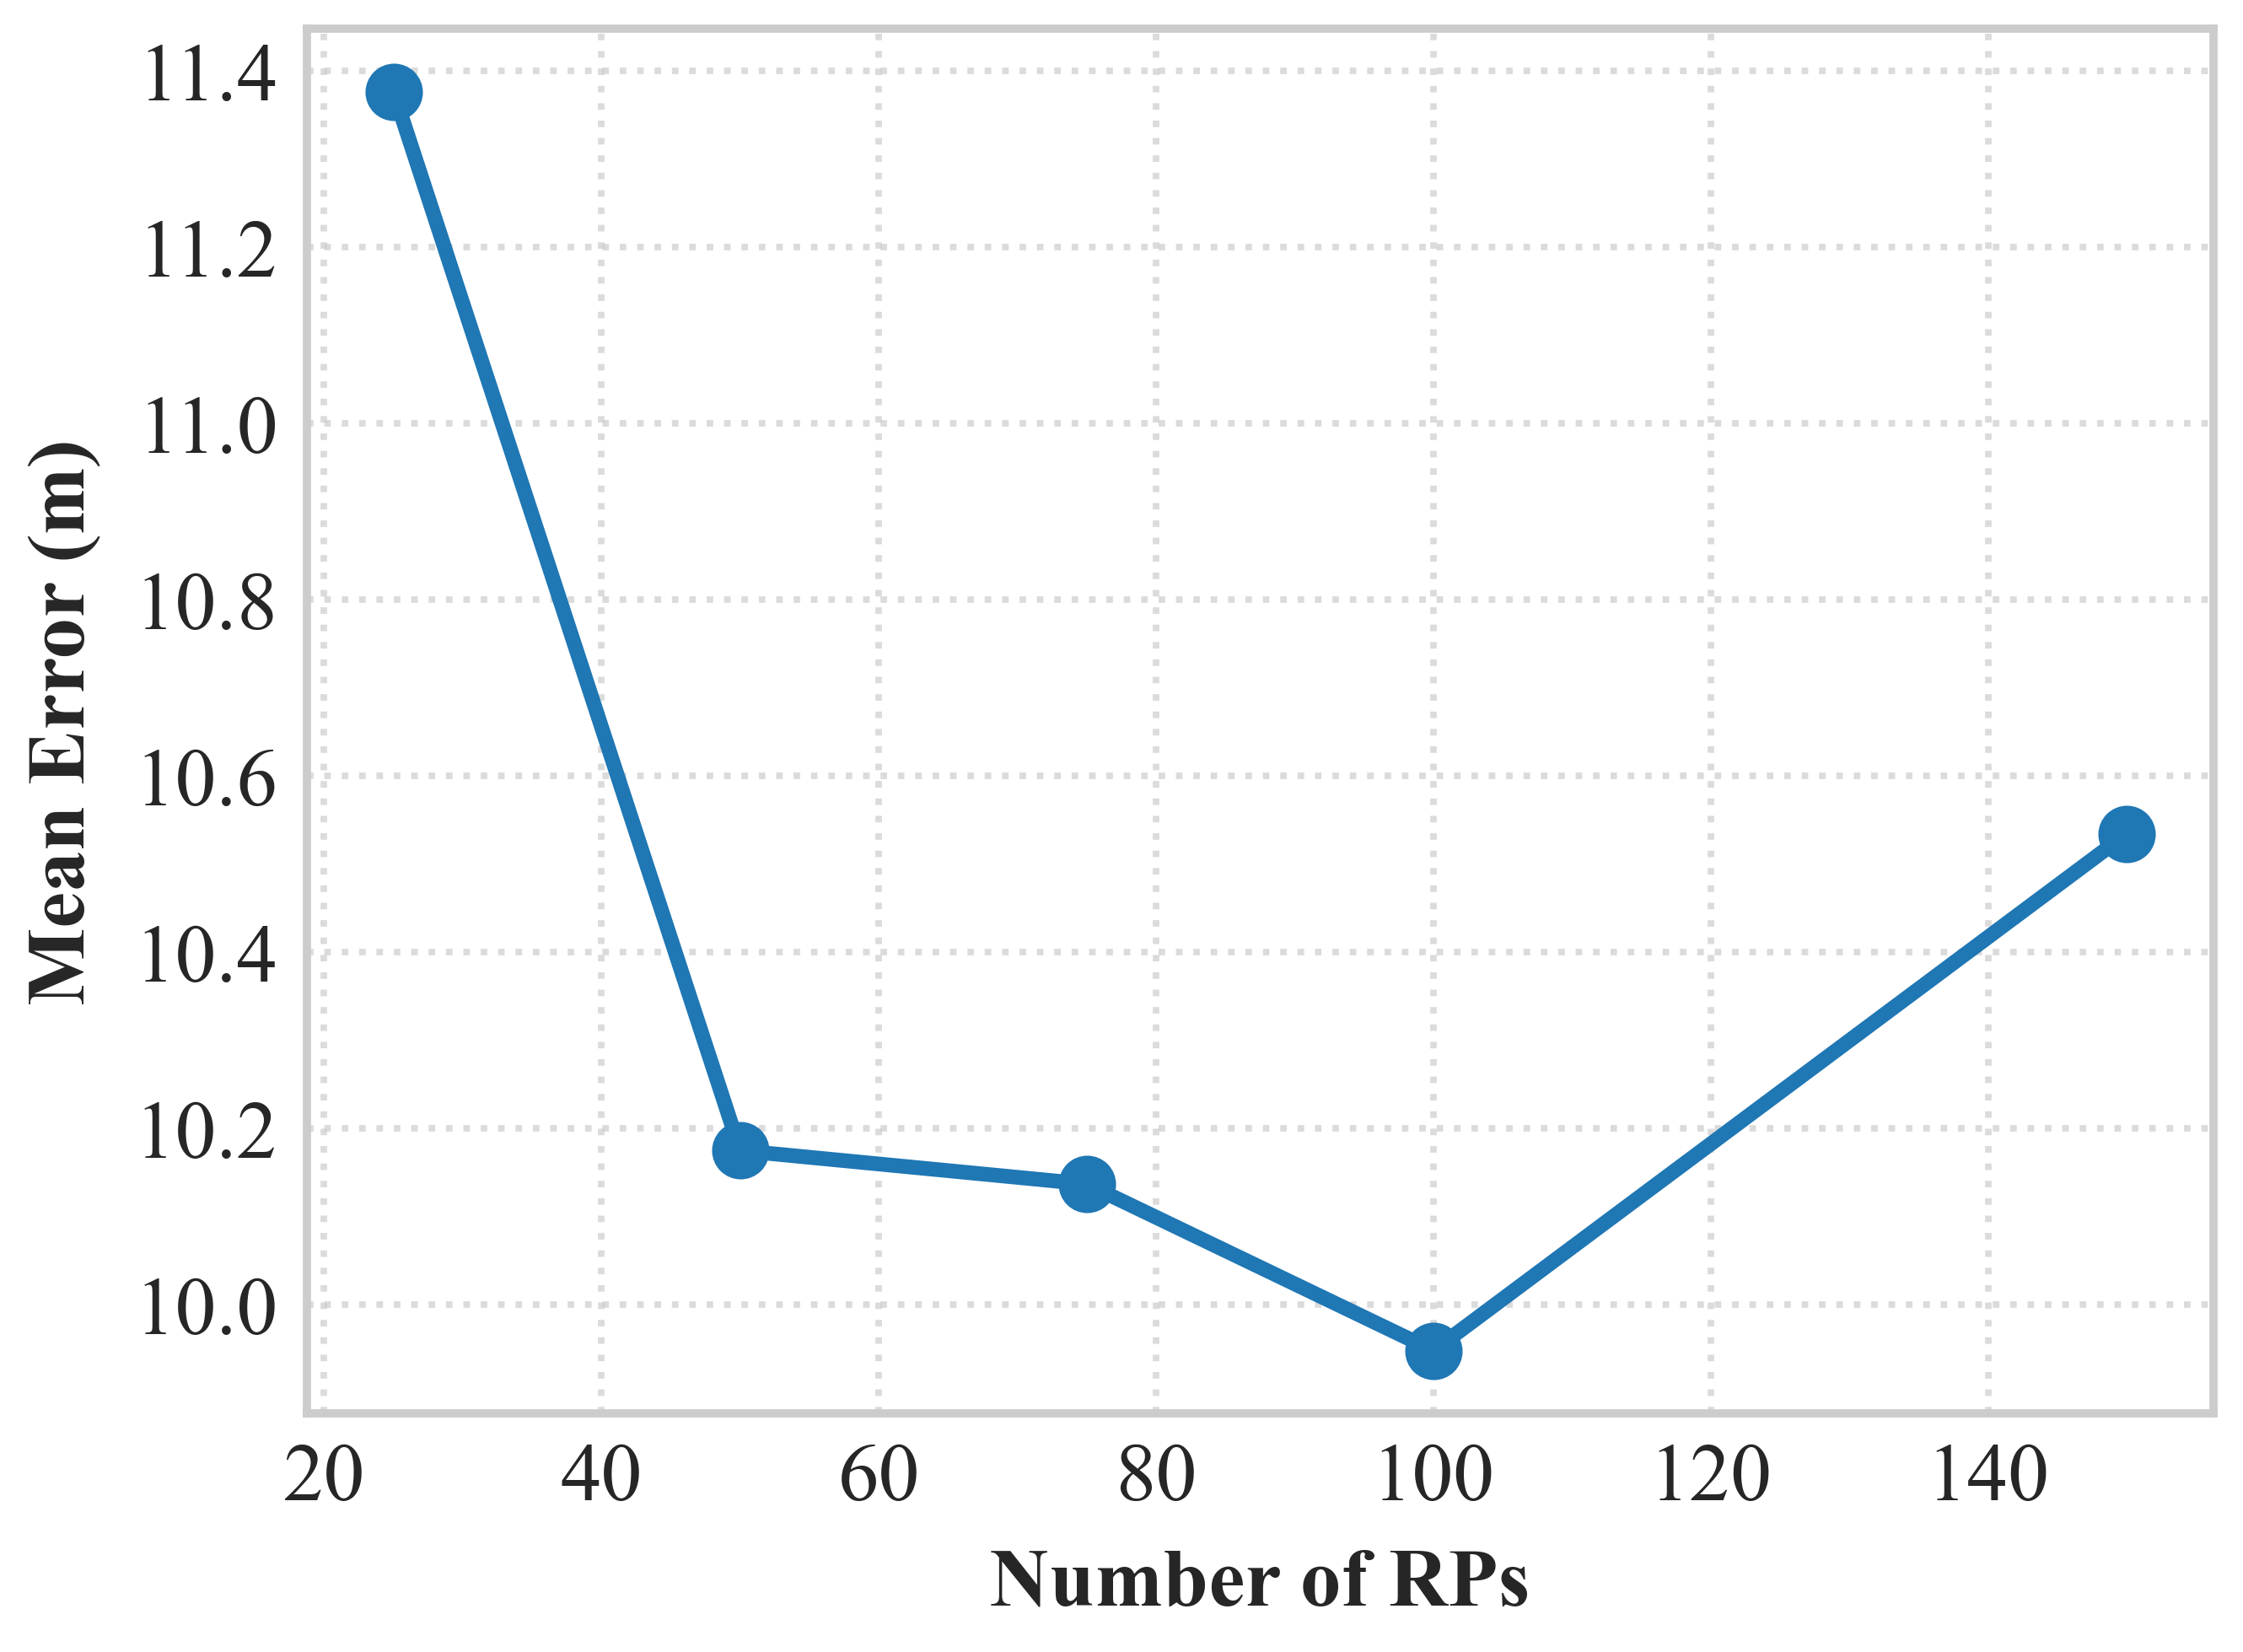

In [52]:
# Mean error vs number of RPs (scalability sweep)
rps_files = sorted(SCALABILITY_DIR.glob('scale_rps_*.json'))
rps_rows = []

for fp in rps_files:
    data = load_json(fp)

    match = re.search(r'scale_rps_(\d+)$', fp.stem)
    max_rps = int(match.group(1)) if match else None
    if max_rps is None:
        continue

    eval_df = collect_eval_points(data)
    if eval_df.empty:
        continue

    final_eval = eval_df.sort_values('round').iloc[-1]
    mean_error = final_eval.get('mean_error')
    if mean_error is None:
        continue

    rps_rows.append({
        'max_rps': int(max_rps),
        'mean_error': float(mean_error)
    })

if not rps_rows:
    print("No RP scalability files found (expected pattern: scale_rps_*.json).")
else:
    rps_df_simple = pd.DataFrame(rps_rows).dropna().sort_values('max_rps')
    display(rps_df_simple)

    figures_dir = RESULTS_DIR / 'figures'
    figures_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(rps_df_simple['max_rps'], rps_df_simple['mean_error'], marker='o', linewidth=1.8)
    ax.set_xlabel('Number of RPs')
    ax.set_ylabel('Mean Error (m)')
    plt.tight_layout()
    fig.savefig(figures_dir / 'fig_scalability_rps_mean_error_ieee.pdf')
    plt.show()